# House Price Prediction — Ames Housing Dataset

**Author:** Amna Arshad — AI Engineer

This notebook builds an end-to-end regression pipeline to predict residential home sale prices using the Ames Housing dataset (Kaggle). It covers data cleaning, exploratory analysis, feature engineering, encoding, feature scaling, and a comparative evaluation of Linear, Ridge, and Lasso Regression — including hyperparameter tuning via GridSearchCV. The final tuned Lasso model is saved for deployment in an interactive Streamlit application.

**Workflow:** Data Cleaning → EDA → Outlier Handling → Feature Engineering → Encoding → Scaling → Model Comparison → Hyperparameter Tuning → Evaluation → Deployment Prep

## 1. Import Libraries

We start by importing the core libraries needed for data manipulation (`pandas`, `numpy`), visualization (`matplotlib`, `seaborn`), and statistical utilities (`scipy.stats`). Display and plotting options are configured upfront so all outputs render consistently throughout the notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

## 2. Load the Dataset

Load the Ames Housing training and test sets (`train.csv`, `test.csv`) from Kaggle. The training set contains the target variable `SalePrice`, while the test set does not — it is what we'll generate final predictions for.

In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()

Train shape: (1460, 81)
Test shape: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 3. Inspect Data Types and Structure

A quick structural overview of the dataset — column names, data types, and non-null counts — to understand what we're working with before diving into deeper analysis.

In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

## 4. Analyze the Target Variable (SalePrice)

Before modeling, it's essential to understand the distribution of the target variable. We check summary statistics and visualize the distribution to detect skewness, which will inform whether a transformation is needed later.

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


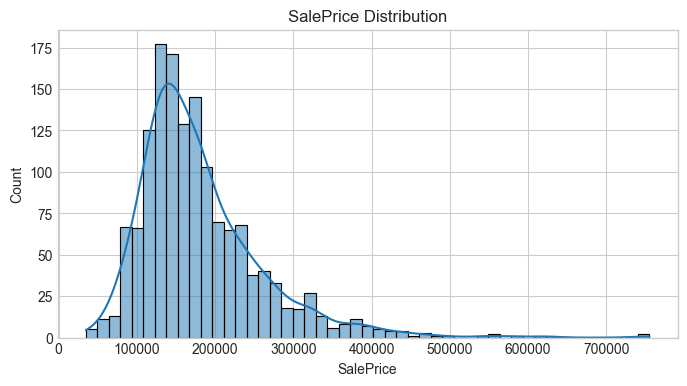

Skewness: 1.8828757597682129


In [4]:
print(train['SalePrice'].describe())

plt.figure(figsize=(8,4))
sns.histplot(train['SalePrice'], kde=True)
plt.title('SalePrice Distribution')
plt.show()

print("Skewness:", train['SalePrice'].skew())

## 5. Identify Missing Values (Training Set)

We calculate the count and percentage of missing values per column. This determines our imputation strategy — columns will be handled differently depending on *why* they're missing (a genuinely absent feature vs. a real data gap), not filled blindly.

In [5]:
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_percent = (missing / len(train)) * 100

missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_percent})
print(missing_df)

              Missing Count  Percentage
PoolQC                 1453   99.520548
MiscFeature            1406   96.301370
Alley                  1369   93.767123
Fence                  1179   80.753425
MasVnrType              872   59.726027
FireplaceQu             690   47.260274
LotFrontage             259   17.739726
GarageType               81    5.547945
GarageYrBlt              81    5.547945
GarageFinish             81    5.547945
GarageQual               81    5.547945
GarageCond               81    5.547945
BsmtExposure             38    2.602740
BsmtFinType2             38    2.602740
BsmtQual                 37    2.534247
BsmtCond                 37    2.534247
BsmtFinType1             37    2.534247
MasVnrArea                8    0.547945
Electrical                1    0.068493


## 6. Handle Missing Values (Training & Test Sets)

Based on the missing value analysis, we apply three strategies:
- **Drop** columns with 90%+ missing data (unreliable for modeling)
- Fill categorical columns where `NaN` means "feature does not exist" (e.g., no garage, no fireplace) with `'None'`
- Impute genuinely missing numerical values with a **grouped median** (e.g., `LotFrontage` by `Neighborhood`) or `0` where appropriate

In [6]:
# 1. Drop columns with too much missing data
cols_to_drop = ['PoolQC', 'MiscFeature', 'Alley', 'Fence']
train.drop(columns=cols_to_drop, inplace=True)
test.drop(columns=cols_to_drop, inplace=True)

# 2. Fill categorical "None" meaning columns
none_cols = ['MasVnrType', 'FireplaceQu', 'GarageType', 'GarageFinish', 
             'GarageQual', 'GarageCond', 'BsmtExposure', 'BsmtFinType1', 
             'BsmtFinType2', 'BsmtQual', 'BsmtCond']

for col in none_cols:
    train[col] = train[col].fillna('None')
    test[col] = test[col].fillna('None')

# 3. LotFrontage - fill with median grouped by Neighborhood
train['LotFrontage'] = train.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))
test['LotFrontage'] = test.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))

# 4. GarageYrBlt, MasVnrArea - fill with 0
train['GarageYrBlt'] = train['GarageYrBlt'].fillna(0)
test['GarageYrBlt'] = test['GarageYrBlt'].fillna(0)
train['MasVnrArea'] = train['MasVnrArea'].fillna(0)
test['MasVnrArea'] = test['MasVnrArea'].fillna(0)

# 5. Electrical - fill with mode
train['Electrical'] = train['Electrical'].fillna(train['Electrical'].mode()[0])

# Check remaining missing in train
print("Remaining missing in train:", train.isnull().sum().sum())

Remaining missing in train: 0


## 7. Check Remaining Missing Values (Test Set)

The test set may still contain missing values not present in training (or vice versa). We check this separately since the test set must be processed with the same logic, but independently verified.

In [7]:
missing_test = test.isnull().sum()
missing_test = missing_test[missing_test > 0].sort_values(ascending=False)
print(missing_test)

MSZoning        4
Utilities       2
BsmtFullBath    2
BsmtHalfBath    2
Functional      2
Exterior2nd     1
Exterior1st     1
BsmtUnfSF       1
BsmtFinSF2      1
BsmtFinSF1      1
TotalBsmtSF     1
KitchenQual     1
GarageCars      1
GarageArea      1
SaleType        1
dtype: int64


## 8. Fill Remaining Test Set Missing Values

The remaining gaps in the test set are minor (1–4 missing values per column) and likely reflect genuine data entry gaps rather than absent features. These are filled using **mode** (categorical) and **0** (numerical, basement/garage related) imputation.

In [8]:
# Categorical - fill with mode
cat_cols = ['MSZoning', 'Utilities', 'Functional', 'Exterior1st', 
            'Exterior2nd', 'KitchenQual', 'SaleType']

for col in cat_cols:
    test[col] = test[col].fillna(test[col].mode()[0])

# Numerical (Basement/Garage related) - fill with 0
num_cols = ['BsmtFullBath', 'BsmtHalfBath', 'BsmtUnfSF', 'BsmtFinSF2', 
            'BsmtFinSF1', 'TotalBsmtSF', 'GarageCars', 'GarageArea']

for col in num_cols:
    test[col] = test[col].fillna(0)

# Verify
print("Remaining missing in test:", test.isnull().sum().sum())

Remaining missing in test: 0


## 9. Visualize Outliers in Key Numerical Features

We plot `GrLivArea` and `TotalBsmtSF` against `SalePrice` to visually identify data points that deviate from the expected linear trend — these are candidates for outlier treatment.

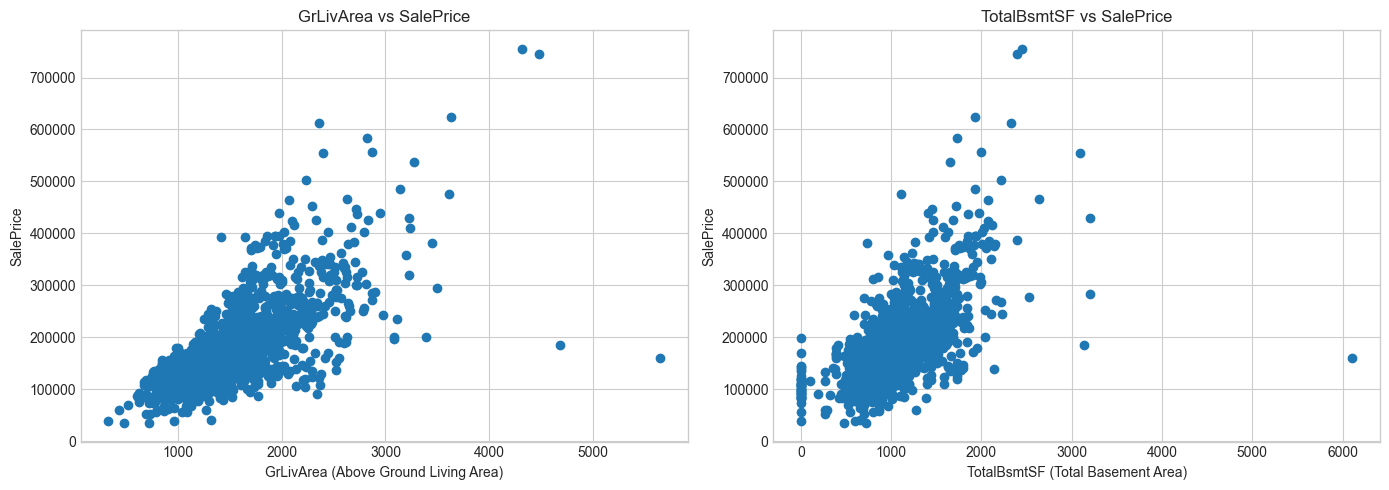

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# GrLivArea vs SalePrice
axes[0].scatter(train['GrLivArea'], train['SalePrice'])
axes[0].set_xlabel('GrLivArea (Above Ground Living Area)')
axes[0].set_ylabel('SalePrice')
axes[0].set_title('GrLivArea vs SalePrice')

# TotalBsmtSF vs SalePrice
axes[1].scatter(train['TotalBsmtSF'], train['SalePrice'])
axes[1].set_xlabel('TotalBsmtSF (Total Basement Area)')
axes[1].set_ylabel('SalePrice')
axes[1].set_title('TotalBsmtSF vs SalePrice')

plt.tight_layout()
plt.show()

## 10. Detect Outliers Using the IQR Method

Since `SalePrice` and related features are right-skewed, the **IQR (Interquartile Range) method** is used to statistically flag outliers rather than the Z-score method (which assumes a normal distribution). This function calculates the lower and upper bounds and returns any values that fall outside them.

In [10]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Check outliers in GrLivArea
outliers_grlivarea, lower, upper = detect_outliers_iqr(train, 'GrLivArea')
print(f"GrLivArea - Lower: {lower:.2f}, Upper: {upper:.2f}")
print(f"Number of outliers: {len(outliers_grlivarea)}")

GrLivArea - Lower: 158.62, Upper: 2747.62
Number of outliers: 31


## 11. Visualize Detected Outliers

Statistically flagged outliers are plotted against the full dataset to visually assess whether they represent genuine data anomalies or simply legitimate high-value properties that should be kept.

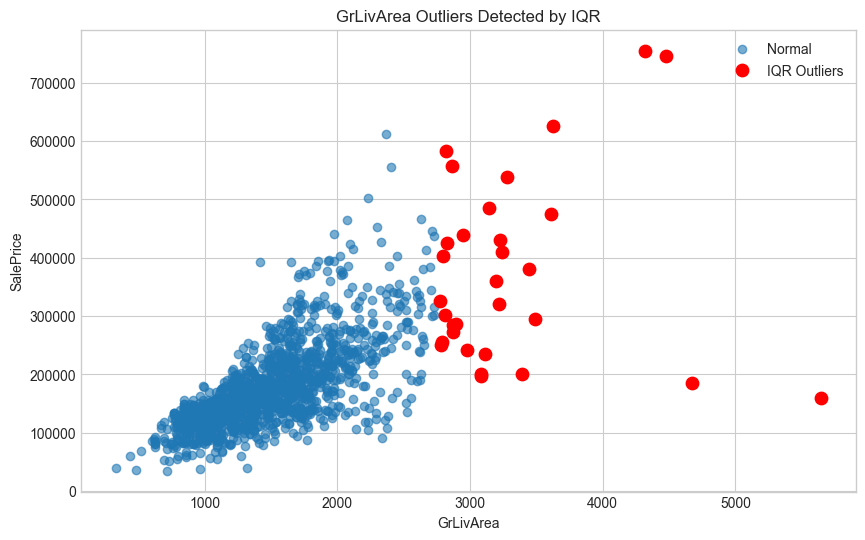

      GrLivArea  SalePrice
1298       5642     160000
523        4676     184750
1182       4476     745000
691        4316     755000
1169       3627     625000
185        3608     475000
304        3493     295000
1268       3447     381000
635        3395     200000
769        3279     538000
1353       3238     410000
496        3228     430000
118        3222     320000
608        3194     359100
798        3140     485000
197        3112     235000
1173       3086     200500
1031       3082     197000
324        2978     242000
58         2945     438780
1024       2898     287000
1175       2872     285000
961        2872     272000
1046       2868     556581
1142       2828     424870
803        2822     582933
1312       2810     302000
231        2794     403000
1328       2792     256000
1386       2784     250000
583        2775     325000


In [11]:
# Visualize outliers detected by IQR
plt.figure(figsize=(10, 6))
plt.scatter(train['GrLivArea'], train['SalePrice'], label='Normal', alpha=0.6)
plt.scatter(outliers_grlivarea['GrLivArea'], outliers_grlivarea['SalePrice'], 
            color='red', label='IQR Outliers', s=80)
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.title('GrLivArea Outliers Detected by IQR')
plt.legend()
plt.show()

# Show the actual outlier rows (GrLivArea + SalePrice only)
print(outliers_grlivarea[['GrLivArea', 'SalePrice']].sort_values('GrLivArea', ascending=False))

## 12. Remove Genuine Outliers

After visual inspection, only the outliers that clearly break the expected pattern (very large living area paired with an unusually low price) are removed. Statistically flagged points that follow a logical trend (e.g., large, expensive homes) are intentionally kept to preserve valid information.

In [12]:
# Remove the 2 genuine outliers (large area but very low price - anomaly)
train = train[~((train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000))]

print("New train shape after outlier removal:", train.shape)

New train shape after outlier removal: (1458, 77)


## 13. Apply Log Transformation to the Target Variable

Since `SalePrice` is right-skewed, we apply a `log1p` transformation to bring its distribution closer to normal. This helps linear models perform better, as they assume a roughly normal target distribution. Skewness is compared before and after to confirm the improvement.

Skewness before log: 1.8812964895244009
Skewness after log: 0.12157976050304882


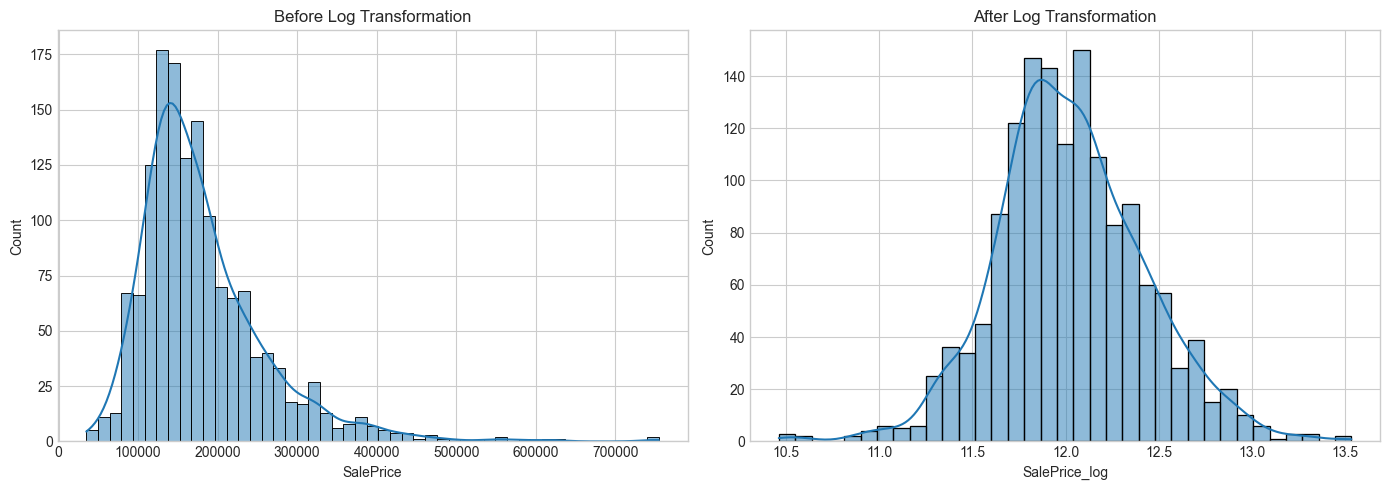

In [13]:
# Before transformation - check skewness
print("Skewness before log:", train['SalePrice'].skew())

# Apply log transformation
train['SalePrice_log'] = np.log1p(train['SalePrice'])

# After transformation - check skewness
print("Skewness after log:", train['SalePrice_log'].skew())

# Visualize before vs after
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(train['SalePrice'], kde=True, ax=axes[0])
axes[0].set_title('Before Log Transformation')

sns.histplot(train['SalePrice_log'], kde=True, ax=axes[1])
axes[1].set_title('After Log Transformation')

plt.tight_layout()
plt.show()

## 14. Identify Categorical Columns

Before encoding, we identify all categorical (object-type) columns in the dataset. These will be split into **ordinal** (have a natural ranking) and **nominal** (no inherent order) groups, each requiring a different encoding strategy.

In [14]:
categorical_cols = train.select_dtypes(include='object').columns.tolist()
print("Total categorical columns:", len(categorical_cols))
print(categorical_cols)

Total categorical columns: 39
['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition']


## 15. Ordinal Encoding — Quality Rating Columns

Columns following the common quality-rating pattern (`Po`, `Fa`, `TA`, `Gd`, `Ex`) are manually mapped to numeric values that preserve their natural ranking. A manual mapping is used instead of `LabelEncoder` to avoid assigning an arbitrary, meaningless order.

In [15]:
# Define the order for quality-based columns (most common pattern in this dataset)
qual_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

qual_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 
             'HeatingQC', 'KitchenQual', 'FireplaceQu', 
             'GarageQual', 'GarageCond']

for col in qual_cols:
    train[col] = train[col].map(qual_map)
    test[col] = test[col].map(qual_map)

print(train[qual_cols].head())

   ExterQual  ExterCond  BsmtQual  BsmtCond  HeatingQC  KitchenQual  \
0          4          3         4         3          5            4   
1          3          3         4         3          5            3   
2          4          3         4         3          5            4   
3          3          3         3         4          4            4   
4          4          3         4         3          5            4   

   FireplaceQu  GarageQual  GarageCond  
0            0           3           3  
1            3           3           3  
2            3           3           3  
3            4           3           3  
4            3           3           3  


## 16. Ordinal Encoding — Remaining Columns with Unique Orders

Several other columns (basement exposure, finish type, garage finish, functionality, lot shape, etc.) each follow their own distinct ranking logic. These are mapped individually based on definitions from the dataset documentation.

In [ ]:
# BsmtExposure -  (No exposure < Minimum < Average < Good)
exposure_map = {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4}
train['BsmtExposure'] = train['BsmtExposure'].map(exposure_map)
test['BsmtExposure'] = test['BsmtExposure'].map(exposure_map)

# BsmtFinType1 & BsmtFinType2 - basement finish quality
fintype_map = {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}
train['BsmtFinType1'] = train['BsmtFinType1'].map(fintype_map)
test['BsmtFinType1'] = test['BsmtFinType1'].map(fintype_map)
train['BsmtFinType2'] = train['BsmtFinType2'].map(fintype_map)
test['BsmtFinType2'] = test['BsmtFinType2'].map(fintype_map)

# GarageFinish 
garagefin_map = {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3}
train['GarageFinish'] = train['GarageFinish'].map(garagefin_map)
test['GarageFinish'] = test['GarageFinish'].map(garagefin_map)

# Functional - home functionality (Typical is best, Salvage is worst)
functional_map = {'Sal': 0, 'Sev': 1, 'Maj2': 2, 'Maj1': 3, 'Mod': 4, 
                   'Min2': 5, 'Min1': 6, 'Typ': 7}
train['Functional'] = train['Functional'].map(functional_map)
test['Functional'] = test['Functional'].map(functional_map)

# LandSlope - Gentle < Moderate < Severe
slope_map = {'Gtl': 0, 'Mod': 1, 'Sev': 2}
train['LandSlope'] = train['LandSlope'].map(slope_map)
test['LandSlope'] = test['LandSlope'].map(slope_map)

# LotShape - Regular is best, Irregular worst
lotshape_map = {'Reg': 0, 'IR1': 1, 'IR2': 2, 'IR3': 3}
train['LotShape'] = train['LotShape'].map(lotshape_map)
test['LotShape'] = test['LotShape'].map(lotshape_map)

# PavedDrive - Not paved < Partial < Paved
paved_map = {'N': 0, 'P': 1, 'Y': 2}
train['PavedDrive'] = train['PavedDrive'].map(paved_map)
test['PavedDrive'] = test['PavedDrive'].map(paved_map)

# Utilities - fewer utilities to all utilities
utilities_map = {'ELO': 0, 'NoSeWa': 1, 'NoSewr': 2, 'AllPub': 3}
train['Utilities'] = train['Utilities'].map(utilities_map)
test['Utilities'] = test['Utilities'].map(utilities_map)

print("Ordinal encoding done!")
print(train[['BsmtExposure', 'BsmtFinType1', 'GarageFinish', 'Functional']].head())

Ordinal encoding done!
   BsmtExposure  BsmtFinType1  GarageFinish  Functional
0             1             6             2           7
1             4             5             2           7
2             2             6             2           7
3             1             5             1           7
4             3             6             2           7


## 17. Identify Remaining Nominal Columns

After ordinal encoding, the columns that remain as `object` dtype have no inherent order (e.g., `Neighborhood`, `Foundation`). These are the candidates for one-hot encoding.

In [17]:
# Remaining nominal (no order) categorical columns
nominal_cols = train.select_dtypes(include='object').columns.tolist()
print("Nominal columns to encode:", len(nominal_cols))
print(nominal_cols)

Nominal columns to encode: 21
['MSZoning', 'Street', 'LandContour', 'LotConfig', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'Heating', 'CentralAir', 'Electrical', 'GarageType', 'SaleType', 'SaleCondition']


## 18. One-Hot Encode Nominal Columns

Nominal columns are one-hot encoded using `pd.get_dummies()`. Training and test sets are combined before encoding to guarantee both datasets end up with identical columns, then split back apart. `drop_first=True` avoids the dummy variable trap and reduces multicollinearity.

In [ ]:
nominal_cols = ['MSZoning', 'Street', 'LandContour', 'LotConfig', 'Neighborhood', 
                 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 
                 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 
                 'Heating', 'CentralAir', 'Electrical', 'GarageType', 'SaleType', 
                 'SaleCondition']

# Combine train and test before encoding to ensure same columns in both
train['is_train'] = 1
test['is_train'] = 0
test['SalePrice'] = 0  
test['SalePrice_log'] = 0

combined = pd.concat([train, test], axis=0)

# One-Hot Encoding
combined = pd.get_dummies(combined, columns=nominal_cols, drop_first=True)

# Split back into train and test
train = combined[combined['is_train'] == 1].drop(['is_train'], axis=1)
test = combined[combined['is_train'] == 0].drop(['is_train', 'SalePrice', 'SalePrice_log'], axis=1)

print("Train shape after encoding:", train.shape)
print("Test shape after encoding:", test.shape)

Train shape after encoding: (1458, 196)
Test shape after encoding: (1459, 194)


## 19. Prepare Feature Matrix (X) and Target (y)

The `Id` column is dropped (not predictive), and the log-transformed `SalePrice_log` is set as the target variable. The processed test set is also finalized here, ready for prediction once a model is trained.

In [19]:
# Save test IDs for final submission later
test_ids = test['Id']

# Drop Id column (not useful for prediction)
X = train.drop(['Id', 'SalePrice', 'SalePrice_log'], axis=1)
y = train['SalePrice_log']   # using log-transformed target

X_test_final = test.drop(['Id'], axis=1)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_test_final shape:", X_test_final.shape)

X shape: (1458, 193)
y shape: (1458,)
X_test_final shape: (1459, 193)


## 20. Train-Validation Split

The training data is split 80/20 into a training set and a hold-out validation set. Since the true `SalePrice` for `test.csv` is unknown, this validation set is what allows us to honestly evaluate model performance on unseen data.

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

X_train shape: (1166, 193)
X_val shape: (292, 193)


## 21. Feature Scaling

Numerical features are standardized using `StandardScaler`. Critically, the scaler is **fit only on the training data** and then used to transform the validation and test sets — fitting separately on any of them would cause data leakage and produce an unreliable evaluation.

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit only on training data, transform train and val
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Transform test data using same scaler
X_test_scaled = scaler.transform(X_test_final)

print("Scaling done!")
print("X_train_scaled shape:", X_train_scaled.shape)

Scaling done!
X_train_scaled shape: (1166, 193)


## 22. Baseline Model — Linear Regression

A simple Linear Regression model is trained first to establish a baseline. Both training and validation RMSE/R² are reported to check for any early signs of overfitting before introducing regularization.

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Predictions
y_train_pred = lr.predict(X_train_scaled)
y_val_pred = lr.predict(X_val_scaled)

# Evaluate
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))

train_r2 = r2_score(y_train, y_train_pred)
val_r2 = r2_score(y_val, y_val_pred)

print("Linear Regression Results:")
print(f"Train RMSE: {train_rmse:.4f}, Train R²: {train_r2:.4f}")
print(f"Val RMSE: {val_rmse:.4f}, Val R²: {val_r2:.4f}")

Linear Regression Results:
Train RMSE: 0.0919, Train R²: 0.9464
Val RMSE: 0.1314, Val R²: 0.8975


## 23. Ridge Regression (L2 Regularization)

Ridge Regression adds an L2 penalty that shrinks coefficient magnitudes, helping reduce overfitting without eliminating any features. Results are compared against the Linear Regression baseline.

In [23]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=10)
ridge.fit(X_train_scaled, y_train)

y_train_pred_ridge = ridge.predict(X_train_scaled)
y_val_pred_ridge = ridge.predict(X_val_scaled)

train_rmse_ridge = np.sqrt(mean_squared_error(y_train, y_train_pred_ridge))
val_rmse_ridge = np.sqrt(mean_squared_error(y_val, y_val_pred_ridge))

train_r2_ridge = r2_score(y_train, y_train_pred_ridge)
val_r2_ridge = r2_score(y_val, y_val_pred_ridge)

print("Ridge Regression Results:")
print(f"Train RMSE: {train_rmse_ridge:.4f}, Train R²: {train_r2_ridge:.4f}")
print(f"Val RMSE: {val_rmse_ridge:.4f}, Val R²: {val_r2_ridge:.4f}")

Ridge Regression Results:
Train RMSE: 0.0930, Train R²: 0.9451
Val RMSE: 0.1258, Val R²: 0.9061


## 24. Lasso Regression (L1 Regularization)

Lasso Regression adds an L1 penalty, which can shrink some coefficients exactly to zero — effectively performing automatic feature selection. We check how many of the original features are eliminated and compare performance against Linear and Ridge.

In [ ]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.001)
lasso.fit(X_train_scaled, y_train)

y_train_pred_lasso = lasso.predict(X_train_scaled)
y_val_pred_lasso = lasso.predict(X_val_scaled)

train_rmse_lasso = np.sqrt(mean_squared_error(y_train, y_train_pred_lasso))
val_rmse_lasso = np.sqrt(mean_squared_error(y_val, y_val_pred_lasso))

train_r2_lasso = r2_score(y_train, y_train_pred_lasso)
val_r2_lasso = r2_score(y_val, y_val_pred_lasso)

print("Lasso Regression Results:")
print(f"Train RMSE: {train_rmse_lasso:.4f}, Train R²: {train_r2_lasso:.4f}")
print(f"Val RMSE: {val_rmse_lasso:.4f}, Val R²: {val_r2_lasso:.4f}")

# Feature Selection Check 
zero_coefs = np.sum(lasso.coef_ == 0)
print(f"\nTotal features: {len(lasso.coef_)}")
print(f"Features eliminated by Lasso (coef = 0): {zero_coefs}")
print(f"Features remaining (coef != 0): {len(lasso.coef_) - zero_coefs}")

Lasso Regression Results:
Train RMSE: 0.0958, Train R²: 0.9417
Val RMSE: 0.1245, Val R²: 0.9081

Total features: 193
Features eliminated by Lasso (coef = 0): 46
Features remaining (coef != 0): 147


## 25. Hyperparameter Tuning with GridSearchCV

Rather than guessing the regularization strength, `GridSearchCV` with 5-fold cross-validation is used to systematically search for the best `alpha` value for both Ridge and Lasso, using cross-validated RMSE as the selection metric.

In [25]:
from sklearn.model_selection import GridSearchCV

# Ridge - alpha search
ridge_params = {'alpha': [0.01, 0.1, 1, 5, 10, 20, 50, 100]}
ridge_grid = GridSearchCV(Ridge(), ridge_params, cv=5, 
                           scoring='neg_root_mean_squared_error')
ridge_grid.fit(X_train_scaled, y_train)

print("Best Ridge alpha:", ridge_grid.best_params_)
print("Best Ridge CV RMSE:", -ridge_grid.best_score_)

# Lasso - alpha search
lasso_params = {'alpha': [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1]}
lasso_grid = GridSearchCV(Lasso(max_iter=5000), lasso_params, cv=5,
                           scoring='neg_root_mean_squared_error')
lasso_grid.fit(X_train_scaled, y_train)

print("\nBest Lasso alpha:", lasso_grid.best_params_)
print("Best Lasso CV RMSE:", -lasso_grid.best_score_)

Best Ridge alpha: {'alpha': 100}
Best Ridge CV RMSE: 0.11979733576520268

Best Lasso alpha: {'alpha': 0.005}
Best Lasso CV RMSE: 0.11612639780621095


## 26. Evaluate Tuned Models

The best-performing Ridge and Lasso models (based on GridSearchCV) are retrained and evaluated on the validation set, allowing a final, fair comparison across all models built so far.

In [26]:
# Best Ridge Model
best_ridge = Ridge(alpha=100)
best_ridge.fit(X_train_scaled, y_train)

y_val_pred_best_ridge = best_ridge.predict(X_val_scaled)
val_rmse_best_ridge = np.sqrt(mean_squared_error(y_val, y_val_pred_best_ridge))
val_r2_best_ridge = r2_score(y_val, y_val_pred_best_ridge)

# Best Lasso Model
best_lasso = Lasso(alpha=0.005, max_iter=5000)
best_lasso.fit(X_train_scaled, y_train)

y_val_pred_best_lasso = best_lasso.predict(X_val_scaled)
val_rmse_best_lasso = np.sqrt(mean_squared_error(y_val, y_val_pred_best_lasso))
val_r2_best_lasso = r2_score(y_val, y_val_pred_best_lasso)

print("Tuned Ridge - Val RMSE:", val_rmse_best_ridge, "| Val R²:", val_r2_best_ridge)
print("Tuned Lasso - Val RMSE:", val_rmse_best_lasso, "| Val R²:", val_r2_best_lasso)

# Feature count check for tuned Lasso
zero_coefs_tuned = np.sum(best_lasso.coef_ == 0)
print(f"\nTuned Lasso - Features eliminated: {zero_coefs_tuned} / {len(best_lasso.coef_)}")

Tuned Ridge - Val RMSE: 0.12986933947749138 | Val R²: 0.8999500585277815
Tuned Lasso - Val RMSE: 0.12347437445764652 | Val R²: 0.9095606890588983

Tuned Lasso - Features eliminated: 128 / 193


## 27. Visualize Actual vs. Predicted Values

An Actual vs. Predicted scatter plot for the best model (tuned Lasso) shows how closely predictions align with true values across the price range — a more intuitive way to assess model fit than metrics alone.

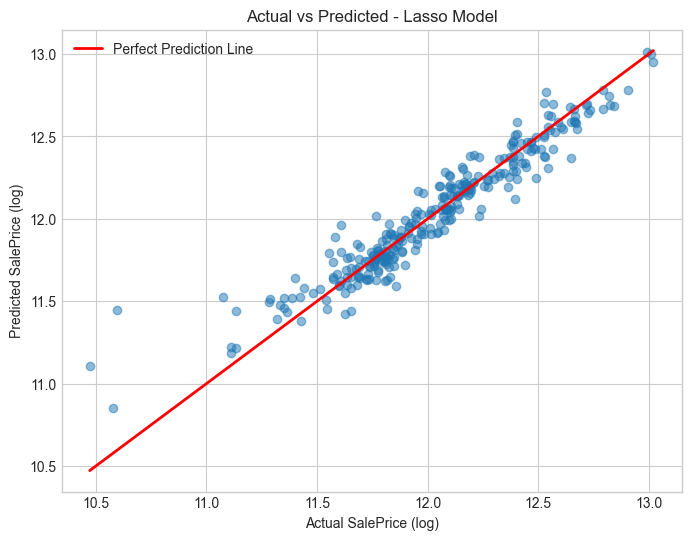

In [27]:
plt.figure(figsize=(8,6))
plt.scatter(y_val, y_val_pred_best_lasso, alpha=0.5)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 
          color='red', linewidth=2, label='Perfect Prediction Line')
plt.xlabel('Actual SalePrice (log)')
plt.ylabel('Predicted SalePrice (log)')
plt.title('Actual vs Predicted - Lasso Model')
plt.legend()
plt.show()

## 28. Generate Predictions on the Test Set

Using the best model (tuned Lasso), we generate predictions on the test set. Since the model was trained on log-transformed prices, predictions are converted back to the original dollar scale using `np.expm1()`.

In [28]:
# Predict using tuned Lasso (best model)
test_predictions_log = best_lasso.predict(X_test_scaled)

# Convert back from log scale to actual SalePrice
test_predictions = np.expm1(test_predictions_log)

# Check predictions
print("Sample predictions:", test_predictions[:10])
print("Min:", test_predictions.min(), "Max:", test_predictions.max())

Sample predictions: [114109.38456149 155597.90163686 176670.90028114 195420.06272532
 194659.20198647 172646.28049123 181875.49800697 163408.07570407
 192965.50964816 120563.3080284 ]
Min: 54884.80909132174 Max: 1730250.0156680858


## 29. Investigate Extreme Predictions

The highest predicted value is inspected in detail to understand its cause. This surfaces an important limitation: predictions for feature combinations far outside the training data's range (extrapolation) can be unreliable.

In [29]:
# Find the index of max prediction
max_idx = np.argmax(test_predictions)
print("Row with highest prediction:")
print("Predicted Price:", test_predictions[max_idx])
print("\nTest ID:", test_ids.iloc[max_idx])

# Check the actual feature values for this row
print("\nKey features for this house:")
print(X_test_final.iloc[max_idx][['GrLivArea', 'OverallQual', 'TotalBsmtSF', 'GarageCars']])

Row with highest prediction:
Predicted Price: 1730250.0156680858

Test ID: 2550

Key features for this house:
GrLivArea        5095
OverallQual        10
TotalBsmtSF    5095.0
GarageCars        3.0
Name: 1089, dtype: object


## 30. Cap Predictions to a Realistic Range

To prevent unrealistic extrapolated predictions from appearing in the final output, predictions are clipped to a reasonable range based on the training data's price bounds (with some margin for legitimately high-value homes).

In [30]:
# Cap predictions within reasonable bounds (based on training data range)
train_max = np.expm1(y_train.max())  # original training max price
train_min = np.expm1(y_train.min())  # original training min price

print("Training price range:", train_min, "-", train_max)

# Cap predictions - allow some margin (e.g., 20% above max) for genuinely large houses
upper_cap = train_max * 1.3
test_predictions_capped = np.clip(test_predictions, train_min * 0.7, upper_cap)

print("\nBefore capping - Max:", test_predictions.max())
print("After capping - Max:", test_predictions_capped.max())

Training price range: 34899.99999999998 - 755000.0000000005

Before capping - Max: 1730250.0156680858
After capping - Max: 981500.0000000006


## 31. Create the Kaggle Submission File

The final, capped predictions are formatted into the `Id` / `SalePrice` structure required by the Kaggle competition and saved as `submission.csv`.

In [31]:
submission = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': test_predictions_capped
})

submission.to_csv('submission.csv', index=False)
print("Final submission file created!")
print(submission.head())
print("\nSubmission stats:")
print(submission['SalePrice'].describe())

Final submission file created!
     Id      SalePrice
0  1461  114109.384561
1  1462  155597.901637
2  1463  176670.900281
3  1464  195420.062725
4  1465  194659.201986

Submission stats:
count      1459.000000
mean     177880.701872
std       77396.056275
min       54884.809091
25%      127076.342756
50%      158005.922553
75%      210490.351281
max      981500.000000
Name: SalePrice, dtype: float64


## 32. Save the Trained Model and Preprocessing Objects

The trained model, fitted scaler, and the exact feature column order are saved using `joblib`. These artifacts are required to make consistent predictions later — for example, inside the Streamlit deployment app.

In [32]:
import joblib

joblib.dump(best_lasso, 'lasso_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns.tolist(), 'feature_columns.pkl')

print("Model, scaler, and feature columns saved successfully!")

Model, scaler, and feature columns saved successfully!


## 33. Save Additional Artifacts for the Streamlit App

Beyond the model itself, the deployment app needs a few extra reference objects: default (median) values for every feature to pre-fill unused inputs, the list of neighborhood options for the dropdown, min/max/median stats for sliders, and the training price bounds used for capping predictions inside the app.

In [ ]:
# 1. Default row (median values of all 193 features) - baseline for predictions
default_row = X.median()
joblib.dump(default_row, 'default_row.pkl')

# 2. Original (pre-encoding) unique values for key categorical features
# Re-read a fresh copy of original categorical columns before encoding for dropdown options
neighborhood_options = sorted([col.replace('Neighborhood_', '') for col in X.columns if col.startswith('Neighborhood_')])
joblib.dump(neighborhood_options, 'neighborhood_options.pkl')

# 3. Save training stats for reference (used for sliders' min/max/default)
feature_stats = {
    'GrLivArea': (int(X['GrLivArea'].min()), int(X['GrLivArea'].max()), int(X['GrLivArea'].median())),
    'TotalBsmtSF': (int(X['TotalBsmtSF'].min()), int(X['TotalBsmtSF'].max()), int(X['TotalBsmtSF'].median())),
    'YearBuilt': (int(X['YearBuilt'].min()), int(X['YearBuilt'].max()), int(X['YearBuilt'].median())),
    'OverallQual': (int(X['OverallQual'].min()), int(X['OverallQual'].max()), int(X['OverallQual'].median())),
    'GarageCars': (int(X['GarageCars'].min()), int(X['GarageCars'].max()), int(X['GarageCars'].median())),
    'FullBath': (int(X['FullBath'].min()), int(X['FullBath'].max()), int(X['FullBath'].median())),
    'BedroomAbvGr': (int(X['BedroomAbvGr'].min()), int(X['BedroomAbvGr'].max()), int(X['BedroomAbvGr'].median())),
    'LotArea': (int(X['LotArea'].min()), int(X['LotArea'].max()), int(X['LotArea'].median())),
}
joblib.dump(feature_stats, 'feature_stats.pkl')

# 4. Training price bounds (for capping in the app too)
train_price_bounds = (float(np.expm1(y_train.min())), float(np.expm1(y_train.max())))
joblib.dump(train_price_bounds, 'train_price_bounds.pkl')

print("All app artifacts saved!")
print("Files needed for app:", ['lasso_model.pkl', 'scaler.pkl', 'feature_columns.pkl', 
                                  'default_row.pkl', 'neighborhood_options.pkl', 
                                  'feature_stats.pkl', 'train_price_bounds.pkl'])

All app artifacts saved!
Files needed for app: ['lasso_model.pkl', 'scaler.pkl', 'feature_columns.pkl', 'default_row.pkl', 'neighborhood_options.pkl', 'feature_stats.pkl', 'train_price_bounds.pkl']
